使用变形模型操作软组织表面的图案到达期望图案

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec

# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [2]:
num = 3
df = pd.read_csv(f'experiment_data{num}.csv')

# 获取并输出列标题
column_titles = df.columns.tolist()
print('Column titles:')
print(column_titles)

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
dot_pixel_np = np.loadtxt(f'dot_pixel_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')

Column titles:
['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


In [3]:
time = df['timestamp'].to_numpy()
time -= time[0]

rob_pose_x = df['actual_TCP_pose_0'].to_numpy()
rob_pose_y = df['actual_TCP_pose_1'].to_numpy()

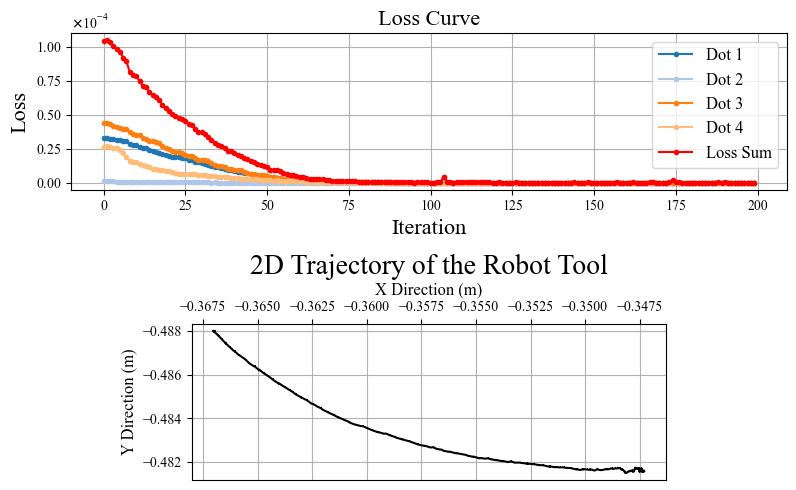

In [12]:
# fig, axs= plt.subplots(3, 1, figsize=(8, 8))
fig = plt.figure(figsize=(8, 5), dpi=100)
gs = GridSpec(2, 1, figure=fig)

# 获取 tab20 颜色映射
colors = plt.cm.tab20.colors

# 定义远离红色的颜色（排除红色及其相近颜色）
filtered_colors = [color for color in colors if not (
    color[0] > 0.8 and color[1] < 0.2 and color[2] < 0.2)]

axs_loss = fig.add_subplot(gs[0, 0])
for i in range(loss_np.shape[1]):
    axs_loss.plot(loss_np[:, i], marker='.', linestyle='-', color=colors[i % len(colors)], label=f'Dot {i+1}')
axs_loss.plot(np.sum(loss_np, axis=1), marker='.', linestyle='-', color='r', label='Loss Sum')
axs_loss.set_title('Loss Curve', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlabel('Iteration', fontsize=16, fontname='Times New Roman')
axs_loss.set_ylabel('Loss', fontsize=16, fontname='Times New Roman')
axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_loss.legend(loc='upper right', fontsize=12)

axs_rob_mov = fig.add_subplot(gs[1, 0])
sample_rate = 50
axs_rob_mov.plot(-rob_pose_x[::sample_rate], rob_pose_y[::sample_rate], marker=',', linestyle='-', color='k', label='Trajectory')
axs_rob_mov.set_title('2D Trajectory of the Robot Tool', fontsize=20, fontname='Times New Roman')
axs_rob_mov.set_xlabel('X Direction (m)', fontsize=12, fontname='Times New Roman')
axs_rob_mov.set_ylabel('Y Direction (m)', fontsize=12, fontname='Times New Roman')
axs_rob_mov.invert_yaxis()
axs_rob_mov.xaxis.set_label_position('top')
axs_rob_mov.xaxis.tick_top()
axs_rob_mov.set_aspect('equal', 'box')

axs = [axs_loss, axs_rob_mov]
for ax in axs:
    ax.grid(True)

plt.tight_layout()
plt.show()